# KEK Power Competitiveness — End-to-End Example

This notebook walks through the full analytical workflow using the precomputed pipeline tables.

**Run the pipeline first** (if outputs don't exist):
```bash
uv run python run_pipeline.py
```

Then open this notebook and run all cells.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from src.assumptions import (
    BASE_WACC_DECIMAL,
    TARIFF_I4_USD_MWH,
    TECH006_CAPEX_USD_PER_KW,
    TECH006_FOM_USD_PER_KW_YR,
    TECH006_LIFETIME_YR,
)
from src.model.basic_model import (
    build_scorecard,
    geas_policy_allocation,
    lcoe_solar,
    resolve_demand,
)

PROCESSED = REPO_ROOT / "outputs" / "data" / "processed"
print(f"Processed tables at: {PROCESSED}")

Processed tables at: /Users/shaanbarca/Desktop/projects/eez/outputs/data/processed


## 1. Load precomputed tables

In [2]:
dim_kek = pd.read_csv(PROCESSED / "dim_kek.csv")
dim_tech_cost = pd.read_csv(PROCESSED / "dim_tech_cost.csv")
fct_resource = pd.read_csv(PROCESSED / "fct_kek_resource.csv")
fct_demand = pd.read_csv(PROCESSED / "fct_kek_demand.csv")
fct_ruptl = pd.read_csv(PROCESSED / "fct_ruptl_pipeline.csv")
fct_grid_cost = pd.read_csv(PROCESSED / "fct_grid_cost_proxy.csv")
fct_lcoe = pd.read_csv(PROCESSED / "fct_lcoe.csv")
fct_scorecard = pd.read_csv(PROCESSED / "fct_kek_scorecard.csv")

print(f"KEKs:          {len(dim_kek)}")
print(f"Resource rows: {len(fct_resource)}")
print(
    f"Demand rows:   {len(fct_demand)}  (demand_mwh_user all null: {fct_demand['demand_mwh_user'].isna().all()})"
)
print(f"RUPTL rows:    {len(fct_ruptl)}  grid regions: {fct_ruptl['grid_region_id'].nunique()}")
print(f"LCOE rows:     {len(fct_lcoe)}  (25 KEKs × 3 WACC values)")
print(f"Scorecard rows:{len(fct_scorecard)}")

KEKs:          25
Resource rows: 25
Demand rows:   25  (demand_mwh_user all null: True)
RUPTL rows:    70  grid regions: 7
LCOE rows:     75  (25 KEKs × 3 WACC values)
Scorecard rows:25


## 2. Scorecard — precomputed (pipeline output)

The pipeline already joined everything and computed LCOE, action flags, and GEAS allocation.
This is the dashboard-ready table.

In [3]:
cols = [
    "kek_name",
    "province",
    "grid_region_id",
    "pvout_best_50km",
    "lcoe_mid_usd_mwh",
    "dashboard_rate_usd_mwh",
    "solar_competitive_gap_pct",
    "solar_attractive",
    "green_share_geas",
    "solar_now",
    "grid_first",
    "firming_needed",
    "plan_late",
]

display = fct_scorecard[cols].copy().sort_values("solar_competitive_gap_pct")
display["pvout_best_50km"] = display["pvout_best_50km"].map("{:.0f}".format)
display["lcoe_mid_usd_mwh"] = display["lcoe_mid_usd_mwh"].map("${:.1f}".format)
display["dashboard_rate_usd_mwh"] = display["dashboard_rate_usd_mwh"].map("${:.2f}".format)
display["solar_competitive_gap_pct"] = display["solar_competitive_gap_pct"].map("{:+.1f}%".format)
display["green_share_geas"] = display["green_share_geas"].map("{:.0%}".format)

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 38)
display

,kek_name,province,grid_region_id,pvout_best_50km,lcoe_mid_usd_mwh,dashboard_rate_usd_mwh,solar_competitive_gap_pct,solar_attractive,green_share_geas,solar_now,grid_first,firming_needed,plan_late
19,Mandalika,West Nusa Tenggara,NTB,1730,$51.5,$63.08,-18.4%,True,0%,False,True,False,False
15,Kura Kura Bali,Bali,JAVA_BALI,1713,$52.0,$63.08,-17.5%,True,48%,True,False,False,False
6,Sanur,Bali,JAVA_BALI,1713,$52.0,$63.08,-17.5%,True,48%,True,False,False,False
9,Singhasari,East Java,JAVA_BALI,1694,$52.6,$63.08,-16.6%,True,48%,True,False,False,False
11,Gresik,East Java,JAVA_BALI,1660,$53.7,$63.08,-14.9%,True,48%,True,False,True,False
12,Likupang,North Sulawesi,SULAWESI,1619,$55.0,$63.08,-12.7%,True,25%,False,False,False,False
13,Bitung,North Sulawesi,SULAWESI,1619,$55.0,$63.08,-12.7%,True,25%,False,False,True,False
0,Industropolis Batang,Central Java,JAVA_BALI,1584,$56.3,$63.08,-10.8%,True,48%,True,False,True,False
7,Kendal,Central Java,JAVA_BALI,1584,$56.3,$63.08,-10.8%,True,48%,True,False,True,False
10,Morotai,North Maluku,MALUKU,1578,$56.5,$63.08,-10.5%,True,0%,False,True,False,False


## 3. Action flag summary

In [4]:
flags = ["solar_now", "grid_first", "firming_needed", "plan_late"]
n = len(fct_scorecard)
grid_ref = fct_scorecard["dashboard_rate_usd_mwh"].iloc[0]

print(f"Base case: WACC=10%  CAPEX=${TECH006_CAPEX_USD_PER_KW}/kW  grid ref=${grid_ref:.2f}/MWh")
print()
for flag in flags:
    count = fct_scorecard[flag].sum()
    pct = count / n * 100
    print(f"  {flag:20s}: {int(count):2d} / {n} KEKs ({pct:.0f}%)")

print()
print("solar_now KEKs:")
solar_now = fct_scorecard[fct_scorecard["solar_now"]][
    ["kek_name", "province", "pvout_best_50km", "lcoe_mid_usd_mwh", "green_share_geas"]
]
if len(solar_now):
    print(solar_now.to_string(index=False))
else:
    print("  None at WACC=10% — try WACC=8% in Section 5 below")

Base case: WACC=10%  CAPEX=$700.0/kW  grid ref=$63.08/MWh

  solar_now           :  6 / 25 KEKs (24%)
  grid_first          :  2 / 25 KEKs (8%)
  firming_needed      :  4 / 25 KEKs (16%)
  plan_late           :  0 / 25 KEKs (0%)

solar_now KEKs:
            kek_name     province  pvout_best_50km  lcoe_mid_usd_mwh  green_share_geas
Industropolis Batang Central Java           1583.7             56.27            0.4801
               Sanur         Bali           1712.9             52.03            0.4801
              Kendal Central Java           1583.7             56.27            0.4801
          Singhasari    East Java           1694.0             52.61            0.4801
              Gresik    East Java           1660.4             53.67            0.4801
      Kura Kura Bali         Bali           1712.9             52.03            0.4801


## 4. Chart — PVOUT vs LCOE quadrant

Blue = solar competitive vs grid. Red = not yet competitive. Dashed lines mark the thresholds.

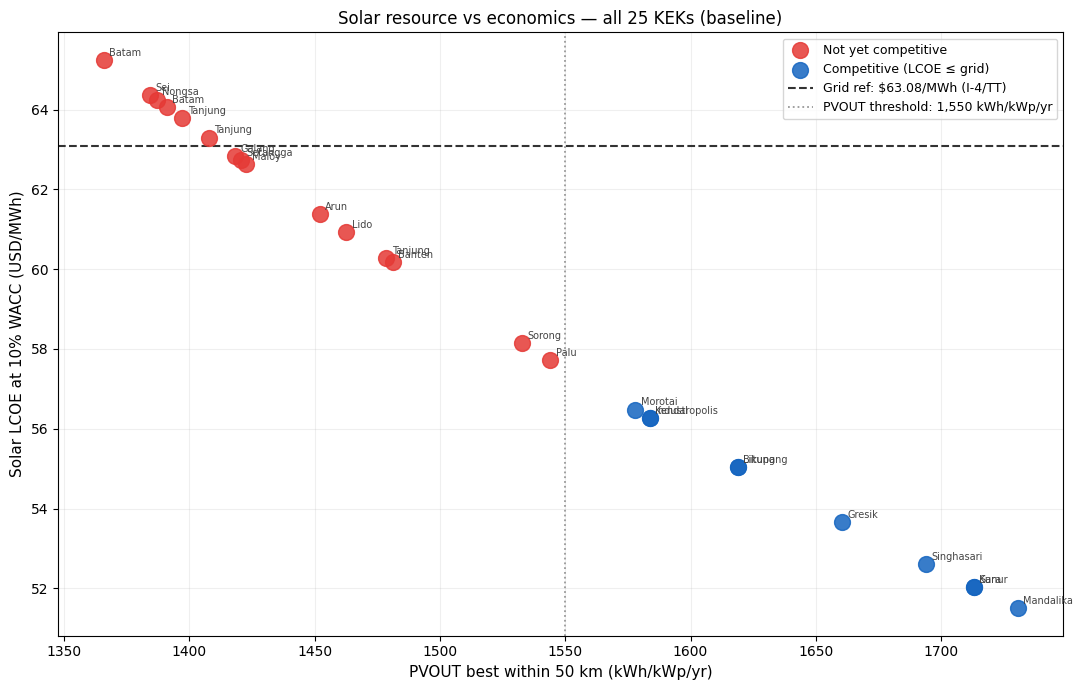

In [5]:
sc = fct_scorecard.copy()

fig, ax = plt.subplots(figsize=(11, 7))

color_map = {True: "#1565C0", False: "#E53935"}
for attractive, grp in sc.groupby("solar_attractive"):
    label = "Competitive (LCOE ≤ grid)" if attractive else "Not yet competitive"
    ax.scatter(
        grp["pvout_best_50km"],
        grp["lcoe_mid_usd_mwh"],
        color=color_map[attractive],
        s=130,
        alpha=0.85,
        zorder=3,
        label=label,
    )

# KEKs with missing solar_attractive (no pvout data)
missing = sc[sc["solar_attractive"].isna()]
if len(missing):
    ax.scatter(
        missing["pvout_best_50km"],
        missing["lcoe_mid_usd_mwh"],
        color="#9E9E9E",
        s=130,
        alpha=0.7,
        zorder=3,
        label="Data missing",
    )

grid_ref = sc["dashboard_rate_usd_mwh"].iloc[0]
ax.axhline(
    grid_ref,
    color="#333",
    linestyle="--",
    linewidth=1.5,
    label=f"Grid ref: ${grid_ref:.2f}/MWh (I-4/TT)",
)
ax.axvline(
    1550, color="#999", linestyle=":", linewidth=1.3, label="PVOUT threshold: 1,550 kWh/kWp/yr"
)

for _, row in sc.iterrows():
    if pd.notna(row["pvout_best_50km"]) and pd.notna(row["lcoe_mid_usd_mwh"]):
        ax.annotate(
            row["kek_name"].split()[0],
            xy=(row["pvout_best_50km"], row["lcoe_mid_usd_mwh"]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=7,
            color="#444",
        )

ax.set_xlabel("PVOUT best within 50 km (kWh/kWp/yr)", fontsize=11)
ax.set_ylabel("Solar LCOE at 10% WACC (USD/MWh)", fontsize=11)
ax.set_title("Solar resource vs economics — all 25 KEKs (baseline)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. WACC sensitivity

How many KEKs flip from not-competitive to competitive as WACC drops from 12% → 8%?

In [6]:
lcoe_wide = fct_lcoe.pivot(index="kek_id", columns="wacc_pct", values="lcoe_mid_usd_mwh").rename(
    columns=lambda w: f"lcoe_{w:.0f}pct"
)

wacc_df = fct_scorecard[["kek_id", "kek_name", "dashboard_rate_usd_mwh"]].merge(
    lcoe_wide.reset_index(), on="kek_id"
)
grid = wacc_df["dashboard_rate_usd_mwh"].iloc[0]

for w in [8, 10, 12]:
    col = f"lcoe_{w}pct"
    competitive = (wacc_df[col] <= grid).sum()
    print(
        f"  WACC {w:2d}%: {competitive:2d} / {len(wacc_df)} KEKs competitive (LCOE <= ${grid:.2f}/MWh)"
    )

print()
# Show KEKs that flip competitive at 8% but not at 10%
borderline = wacc_df[(wacc_df["lcoe_10pct"] > grid) & (wacc_df["lcoe_8pct"] <= grid)][
    ["kek_name", "lcoe_8pct", "lcoe_10pct", "lcoe_12pct"]
]

if len(borderline):
    print("KEKs that become competitive at 8% WACC (but not at 10%):")
    print(borderline.to_string(index=False))
else:
    print("No KEKs flip between 8% and 10% WACC")

KeyError: 'lcoe_mid_usd_mwh'

## 6. Demand override — adjust a single KEK's demand

`demand_mwh_user` is null by default (pipeline uses area × intensity). Override it here and re-run `build_scorecard()` to see the effect on GEAS allocation.

In [7]:
# Override: Industropolis Batang demand = 5,000 GWh/yr (large industrial anchor)
OVERRIDE_KEK = "industropolis-batang"
OVERRIDE_DEMAND_MWH = 5_000_000  # 5 TWh/yr

fct_demand_override = fct_demand.copy()
fct_demand_override.loc[fct_demand_override["kek_id"] == OVERRIDE_KEK, "demand_mwh_user"] = (
    OVERRIDE_DEMAND_MWH
)

# resolve_demand() coalesces: demand_mwh_user takes precedence when non-null
fct_demand_resolved = resolve_demand(fct_demand_override)

original_demand = fct_demand[fct_demand["kek_id"] == OVERRIDE_KEK]["demand_mwh"].iloc[0]
resolved_demand = fct_demand_resolved[fct_demand_resolved["kek_id"] == OVERRIDE_KEK][
    "demand_mwh"
].iloc[0]

print(f"Original demand (area x intensity): {original_demand:,.0f} MWh")
print(f"User override:                       {OVERRIDE_DEMAND_MWH:,.0f} MWh")
print(f"Resolved (after resolve_demand):     {resolved_demand:,.0f} MWh")

Original demand (area x intensity): 2,124,736 MWh
User override:                       5,000,000 MWh
Resolved (after resolve_demand):     5,000,000 MWh


In [8]:
# Re-run build_scorecard() with the overridden demand
tech = dim_tech_cost[dim_tech_cost["tech_id"] == "TECH006"].iloc[0]
grid_ref = fct_grid_cost["dashboard_rate_usd_mwh"].iloc[0]

scorecard_override = build_scorecard(
    dim_kek=dim_kek[["kek_id", "kek_name", "province", "grid_region_id", "reliability_req"]],
    fct_demand=fct_demand_resolved,
    fct_pvout=fct_resource[["kek_id", "pvout_centroid", "pvout_best_50km"]],
    fct_ruptl=fct_ruptl,
    capex_usd_per_kw=float(tech["capex_usd_per_kw"]),
    fom_usd_per_kw_yr=float(tech["fom_usd_per_kw_yr"]),
    wacc=BASE_WACC_DECIMAL,
    lifetime_yr=int(tech["lifetime_yr"]),
    grid_cost_usd_mwh=grid_ref,
)

# Compare GEAS share before/after override for Industropolis Batang
baseline_geas = fct_scorecard[fct_scorecard["kek_id"] == OVERRIDE_KEK]["green_share_geas"].iloc[0]
override_geas = scorecard_override[scorecard_override["kek_id"] == OVERRIDE_KEK][
    "green_share_geas"
].iloc[0]

print(f"GEAS green share — baseline:  {baseline_geas:.1%}")
print(f"GEAS green share — override:  {override_geas:.1%}")
print()
print(
    "Explanation: higher demand → smaller green share (same regional RUPTL solar, bigger KEK denominator)"
)

KeyError: 'fom_usd_per_kw_yr'

## 7. Policy scenario — GEAS allocation comparison

Policy accelerates 20% of post-2030 RUPTL solar into the pre-2030 window, then allocates by `demand × PVOUT` priority weighting instead of pure pro-rata.

In [10]:
policy_input = fct_scorecard[
    ["kek_id", "kek_name", "grid_region_id", "demand_mwh", "pvout_best_50km"]
].copy()
policy_result = geas_policy_allocation(
    kek_df=policy_input,
    ruptl_df=fct_ruptl,
    shift_fraction=0.20,
)

compare = (
    policy_result[["kek_id", "kek_name", "green_share_geas_policy"]]
    .merge(
        fct_scorecard[["kek_id", "green_share_geas"]],
        on="kek_id",
    )
    .sort_values("green_share_geas_policy", ascending=False)
)

flip = ((compare["green_share_geas"] < 0.30) & (compare["green_share_geas_policy"] >= 0.30)).sum()
print(f"KEKs crossing 30% threshold under policy (not baseline): {flip}")
print()

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(compare))
w = 0.38
ax.bar(x - w / 2, compare["green_share_geas"], w, label="Baseline (pro-rata)", color="#90CAF9")
ax.bar(
    x + w / 2,
    compare["green_share_geas_policy"],
    w,
    label="Policy (demand x PVOUT)",
    color="#1565C0",
)
ax.axhline(0.30, color="#E53935", linestyle="--", linewidth=1.2, label="30% solar_now threshold")
ax.set_xticks(x)
ax.set_xticklabels(compare["kek_name"].str.split().str[0], rotation=40, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("GEAS green share")
ax.set_title("Baseline vs. policy scenario — GEAS green share per KEK (20% RUPTL acceleration)")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

KeyError: "['demand_mwh'] not in index"

## 8. Single-function LCOE calculation

For quick sensitivity analysis without loading all the tables.

In [11]:
from src.model.basic_model import capacity_factor_from_pvout, lcoe_solar_with_firming

# Scenario: KEK in East Java, good solar resource
pvout_annual = 1620  # kWh/kWp/yr (from GeoTIFF)
cf = capacity_factor_from_pvout(pvout_annual)
print(f"PVOUT {pvout_annual} kWh/kWp/yr  →  CF = {cf:.2%}")
print()

grid = TARIFF_I4_USD_MWH
print(f"Grid reference (I-4/TT): ${grid:.2f}/MWh")
print()
print(f"{'WACC':>6}  {'CAPEX':>8}  {'LCOE':>10}  {'Gap vs grid':>12}  {'Competitive?':>12}")
print("-" * 58)

for wacc in [0.08, 0.10, 0.12]:
    for capex in [600, 700, 850]:
        l = lcoe_solar(capex, TECH006_FOM_USD_PER_KW_YR, wacc, TECH006_LIFETIME_YR, cf)
        gap = (l - grid) / grid * 100
        print(
            f"{wacc * 100:>5.0f}%  ${capex:>6}/kW  ${l:>8.2f}/MWh  {gap:>+10.1f}%  {'YES' if l <= grid else 'no':>12}"
        )

print()
# With firming adder (for high-reliability KEKs)
l_firm = lcoe_solar_with_firming(
    700, TECH006_FOM_USD_PER_KW_YR, 0.10, TECH006_LIFETIME_YR, cf, firming_adder="mid"
)
print(
    f"With mid firming adder (+$11/MWh): ${l_firm:.2f}/MWh  ({'competitive' if l_firm <= grid else 'not competitive'} vs I-4/TT)"
)

PVOUT 1620 kWh/kWp/yr  →  CF = 18.49%

Grid reference (I-4/TT): $63.08/MWh

  WACC     CAPEX        LCOE   Gap vs grid  Competitive?
----------------------------------------------------------
    8%  $   600/kW  $   42.10/MWh       -33.3%           YES
    8%  $   700/kW  $   47.89/MWh       -24.1%           YES
    8%  $   850/kW  $   56.56/MWh       -10.3%           YES
   10%  $   600/kW  $   48.21/MWh       -23.6%           YES
   10%  $   700/kW  $   55.01/MWh       -12.8%           YES
   10%  $   850/kW  $   65.21/MWh        +3.4%            no
   12%  $   600/kW  $   54.63/MWh       -13.4%           YES
   12%  $   700/kW  $   62.50/MWh        -0.9%           YES
   12%  $   850/kW  $   74.31/MWh       +17.8%            no

With mid firming adder (+$11/MWh): $66.01/MWh  (not competitive vs I-4/TT)
